<a href="https://colab.research.google.com/github/solaxttp/ml/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Завантажуємо файл train.csv
df = pd.read_csv('train.csv')

# 2. Обираємо найсильніші числові та категоріальні ознаки
numerical_features = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GarageCars']
categorical_features = ['Neighborhood', 'KitchenQual']
target = 'SalePrice'

# Залишаємо тільки потрібні колонки
data = df[numerical_features + categorical_features + [target]].dropna().copy()

# 3. Розділяємо дані на Train (60%), Validation (20%), Test (20%) ДО трансформацій
X = data.drop(columns=[target])
y = data[target].values.reshape(-1, 1)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 4. Кодування категорій (Ordinal + One-Hot)
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1}
for df_part in [X_train, X_val, X_test]:
    df_part['KitchenQual'] = df_part['KitchenQual'].map(qual_map).fillna(3)

X_train = pd.get_dummies(X_train, columns=['Neighborhood'], drop_first=True)
X_val = pd.get_dummies(X_val, columns=['Neighborhood'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Neighborhood'], drop_first=True)

# Вирівнюємо колонки між вибірками
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 5. Масштабування (StandardScaler) — fit робимо ТІЛЬКИ на Train!
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
X_test_scaled = scaler_x.transform(X_test)

# Масштабуємо ціну для стабільності
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

print("Дані підготовлено успішно!")
print(f"Розміри: Train {X_train_scaled.shape}, Val {X_val_scaled.shape}, Test {X_test_scaled.shape}")

Дані підготовлено успішно!
Розміри: Train (876, 30), Val (292, 30), Test (292, 30)


In [2]:
class CustomLinearRegression:
    def __init__(self):
        self.w = None
        self.b = None

    def fit_batch_gd(self, X, y, lr=0.01, epochs=500):
        m, n = X.shape
        self.w = np.zeros((n, 1))
        self.b = 0
        loss_history = []

        for epoch in range(epochs):
            y_pred = X @ self.w + self.b
            loss = np.mean((y_pred - y) ** 2) / 2
            loss_history.append(loss)

            dw = (1 / m) * (X.T @ (y_pred - y))
            db = (1 / m) * np.sum(y_pred - y)

            self.w -= lr * dw
            self.b -= lr * db

        return loss_history

    def fit_sgd(self, X, y, lr=0.01, epochs=50):
        m, n = X.shape
        self.w = np.zeros((n, 1))
        self.b = 0
        loss_history = []

        for epoch in range(epochs):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(m):
                xi = X_shuffled[i:i+1]
                yi = y_shuffled[i:i+1]

                y_pred = xi @ self.w + self.b
                dw = xi.T @ (y_pred - yi)
                db = np.sum(y_pred - yi)

                self.w -= lr * dw
                self.b -= lr * db

            full_pred = X @ self.w + self.b
            loss_history.append(np.mean((full_pred - y) ** 2) / 2)

        return loss_history

    def fit_minibatch_gd(self, X, y, lr=0.01, epochs=100, batch_size=32):
        m, n = X.shape
        self.w = np.zeros((n, 1))
        self.b = 0
        loss_history = []

        for epoch in range(epochs):
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            for i in range(0, m, batch_size):
                Xi = X_shuffled[i:i+batch_size]
                yi = y_shuffled[i:i+batch_size]
                b_size = Xi.shape[0]

                y_pred = Xi @ self.w + self.b
                dw = (1 / b_size) * (Xi.T @ (y_pred - yi))
                db = (1 / b_size) * np.sum(y_pred - yi)

                self.w -= lr * dw
                self.b -= lr * db

            full_pred = X @ self.w + self.b
            loss_history.append(np.mean((full_pred - y) ** 2) / 2)

        return loss_history

    def predict(self, X):
        return X @ self.w + self.b

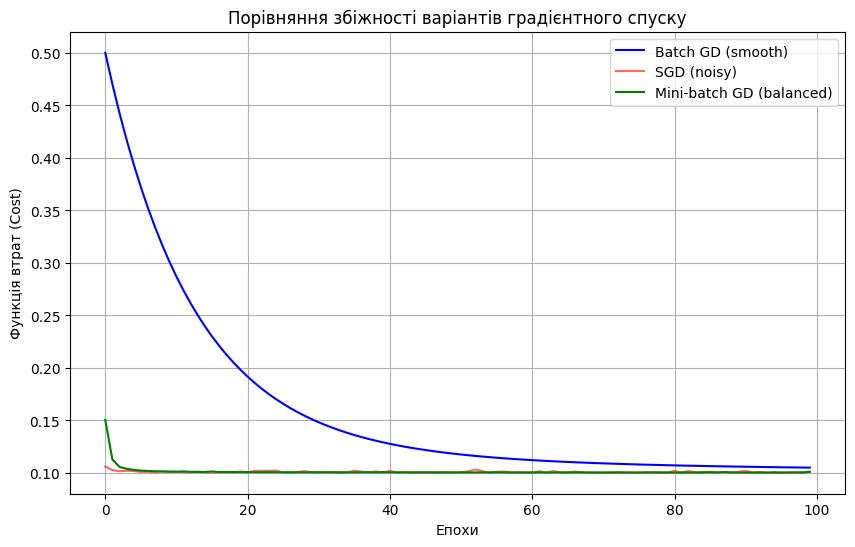

In [3]:
model_batch = CustomLinearRegression()
loss_batch = model_batch.fit_batch_gd(X_train_scaled, y_train_scaled, lr=0.01, epochs=100)

model_sgd = CustomLinearRegression()
loss_sgd = model_sgd.fit_sgd(X_train_scaled, y_train_scaled, lr=0.001, epochs=100)

model_mini = CustomLinearRegression()
loss_mini = model_mini.fit_minibatch_gd(X_train_scaled, y_train_scaled, lr=0.01, epochs=100, batch_size=32)

plt.figure(figsize=(10, 6))
plt.plot(loss_batch, label='Batch GD (smooth)', color='blue')
plt.plot(loss_sgd, label='SGD (noisy)', color='red', alpha=0.6)
plt.plot(loss_mini, label='Mini-batch GD (balanced)', color='green')
plt.xlabel('Епохи')
plt.ylabel('Функція втрат (Cost)')
plt.title('Порівняння збіжності варіантів градієнтного спуску')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def r2_score_custom(y_true, y_pred):
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (rss / tss)

# Предсказання на всіх 3 вибірках
pred_train = model_mini.predict(X_train_scaled)
pred_val = model_mini.predict(X_val_scaled)
pred_test = model_mini.predict(X_test_scaled)

# Обчислюємо R2
r2_train = r2_score_custom(y_train_scaled, pred_train)
r2_val = r2_score_custom(y_val_scaled, pred_val)
r2_test = r2_score_custom(y_test_scaled, pred_test)

print(f"R² на Train: {r2_train:.4f}")
print(f"R² на Validation: {r2_val:.4f}")
print(f"R² на Test: {r2_test:.4f}")

R² на Train: 0.7981
R² на Validation: 0.8066
R² на Test: 0.8248


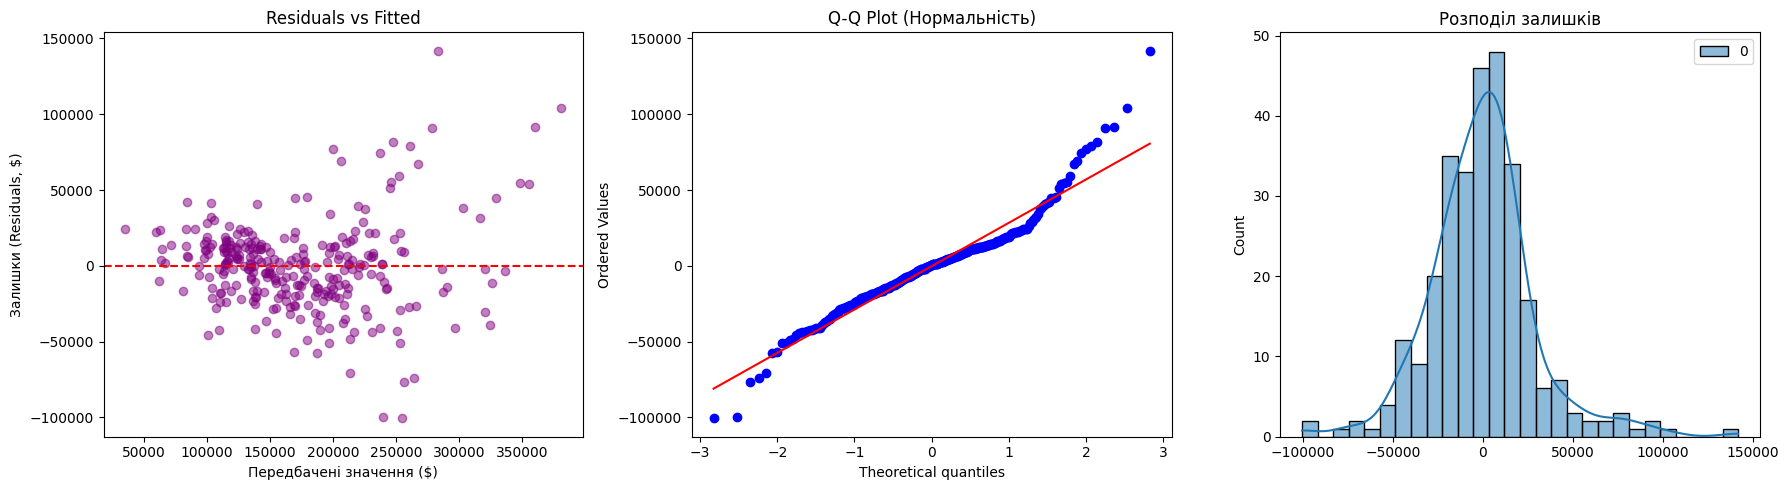

In [5]:
import scipy.stats as stats

# Рахуємо помилки (залишки) у звичайних доларах
residuals = scaler_y.inverse_transform(y_test_scaled) - scaler_y.inverse_transform(pred_test)
fitted = scaler_y.inverse_transform(pred_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Графік Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.5, color='purple')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Передбачені значення ($)')
axes[0].set_ylabel('Залишки (Residuals, $)')
axes[0].set_title('Residuals vs Fitted')

# 2. Q-Q Plot
stats.probplot(residuals.flatten(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Нормальність)')

# 3. Гістограма залишків
sns.histplot(residuals, kde=True, ax=axes[2], color='teal')
axes[2].set_title('Розподіл залишків')

plt.tight_layout()
plt.show()

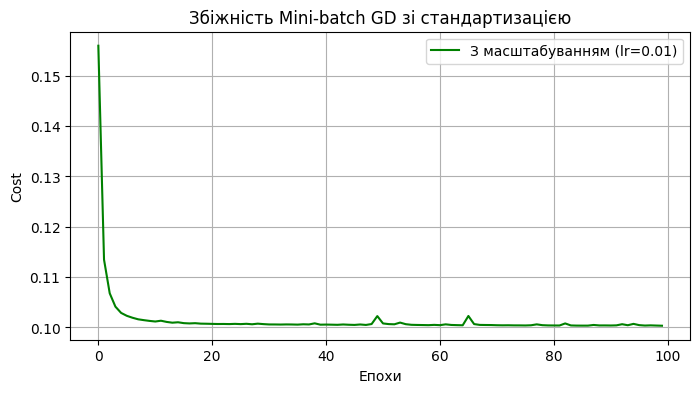

Висновок: Без масштабування даних матриця параметрів має величезний розкид значень, тому градієнтний спуск вимагає мікроскопічного krokу (1e-10) і збігається в рази повільніше!


In [6]:
# Запустимо навчальний процес зі стандартизацією для наочності
model_scaled = CustomLinearRegression()
loss_scaled = model_scaled.fit_minibatch_gd(X_train_scaled, y_train_scaled, lr=0.01, epochs=100)

plt.figure(figsize=(8, 4))
plt.plot(loss_scaled, label='З масштабуванням (lr=0.01)', color='green')
plt.xlabel('Епохи')
plt.ylabel('Cost')
plt.title('Збіжність Mini-batch GD зі стандартизацією')
plt.legend()
plt.grid(True)
plt.show()

print("Висновок: Без масштабування даних матриця параметрів має величезний розкид значень, тому градієнтний спуск вимагає мікроскопічного krokу (1e-10) і збігається в рази повільніше!")